Import Statements

In [1]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import czifile
import cv2 as cv
from cellpose import models
from shapely import Polygon, distance
from skimage import exposure, morphology
from skimage.filters import threshold_otsu, gaussian
from skimage.measure import label, regionprops, find_contours
from skimage.morphology import remove_small_objects, disk, binary_dilation
from skimage.segmentation import relabel_sequential, clear_border

PARAMETERS

In [2]:
IMAGE_FOLDER   = "102225_MFI_lipid_droplet_starvation"
FILE_EXTENSION = "*.czi"
RESULTS_FOLDER = "Results"

USE_GPU            = True
CELLPOSE_DIAMETER  = 160 #Too high = merges cells; too low = splits cells
#old: 120

#cell-segmentation thresholds
FLOW_THRESH_BRIGHT = 0.8 #Lower = stricter, fewer false cells
#0.6, old 0.7
PROB_THRESH_BRIGHT = -15 #More negative = accepts dimmer/weaker cells ADJUST THIS!!!
#-3
FLOW_THRESH_DIM    = 0.3
PROB_THRESH_DIM    = -6.0 #More negative = casts wider net for faint dim cells
CELL_MIN_AREA      = 300 #Lower = keeps smaller cells

#mitochondria segmentation thresholds
MINIMUM_MITO_THRESH = 0.1

OUTPUT_FILENAME = "102225_lipid_mfi_per_cell.csv"

os.makedirs(RESULTS_FOLDER, exist_ok=True)

#init cellpose 3 model (tries cyto3, falls back to cyto2 if download fails)
print("Initializing Cellpose 3 (cyto3)...")
try:
    model = models.Cellpose(gpu=USE_GPU, model_type='cyto3')
    print(f"  cyto3 ready  |  GPU={USE_GPU}")
except Exception as e:
    print(f"  cyto3 failed ({e}), falling back to cyto2")
    model = models.Cellpose(gpu=USE_GPU, model_type='cyto2')
print("Parameters set.")

Initializing Cellpose 3 (cyto3)...
  cyto3 ready  |  GPU=True
Parameters set.


Helper Functions

In [3]:
contours = []

def normalize_image(image): #returns normalized image
    """Min-max normalize to float64 [0, 1]."""
    img = image.astype(np.float64)
    mn, mx = img.min(), img.max()
    return np.zeros_like(img) if mx == mn else (img - mn) / (mx - mn)


def boost_contrast_visual(image): #returns image with improved exposure
    """Percentile stretch for DISPLAY ONLY."""
    p_lo, p_hi = np.percentile(image, (1, 99.5))
    return exposure.rescale_intensity(image, in_range=(p_lo, p_hi))


def load_channels(filepath):
    """Load .czi and return (green_raw, red_raw) as 2D arrays."""
    try:
        czi = czifile.CziFile(filepath)
        img = np.squeeze(czi.asarray())
    except Exception as e:
        print(f"  [ERROR] File load failed: {e}")
        return None, None

    ch0 = ch1 = None
    if img.ndim == 3 and img.shape[0] in (2, 3, 4):
        ch0, ch1 = img[0], img[1]
    elif img.ndim == 3 and img.shape[-1] in (2, 3, 4):
        ch0, ch1 = img[..., 0], img[..., 1]
    else:
        print(f"  [ERROR] Unexpected shape: {img.shape}")
        return None, None

    return (ch0, ch1)


# ── CELL SEGMENTATION — dual-pass Cellpose 3 ──────────────────────────────────
def segment_cells_single_pass(nuclei_channel, cyto_channel):
    """
    Single-pass Cellpose 3 segmentation.

    This removes the bright/dim two-pass merge logic, which can introduce
    odd shapes and missed cells when the two passes disagree. The function
    runs Cellpose once on a gently normalized image and then applies only
    minimal cleanup.
    Returns a 2D integer label array (0=background, 1..N=cells).
    """
    if model is None:
        print("  [ERROR] Model not initialized.")
        return None

    nuclei_norm = normalize_image(nuclei_channel).astype(np.float32)
    cyto_norm = normalize_image(cyto_channel).astype(np.float32)
    img_2ch = np.stack([cyto_norm, nuclei_norm], axis=-1)
    # Channel 1: Cytoplasm - Blue
    # Channel 2: Nuclei - Red
    eval_result = model.eval(
        img_2ch,
        diameter=CELLPOSE_DIAMETER,
        channels=[1, 2],
        flow_threshold=FLOW_THRESH_BRIGHT,
        cellprob_threshold=PROB_THRESH_BRIGHT,
        do_3D=False,
        resample=True,
    )
    masks = eval_result[0]
    print(f"    Single pass:     {masks.max()} masks")

    cleaned = masks.copy().astype(np.int32)

    for rid in range(1, int(cleaned.max()) + 1):
        if (cleaned == rid).sum() < CELL_MIN_AREA:
            cleaned[cleaned == rid] = 0
    final, _, _ = relabel_sequential(cleaned)
    print(f"    Final cells:     {final.max()}")
    return final # integer mask


"""
Adative Threshold Segmentation:
OpenCV's adaptive threshold function returns an image with only the foreground. Image is broken
up into blocks, and if a pixel is greater than the mean - C parameter for the block, the pixel is included. Otherwise
the pixel value becomes 0.
"""

def segment_mito_adaptive(blue_raw):
    blue_uint8 = (normalize_image(blue_raw) * 255).astype(np.uint8)
    blue_blurred = cv.medianBlur(blue_uint8, 5)
    mito_filtered = cv.adaptiveThreshold(blue_blurred, 10, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, -3)
    binary_mito = mito_filtered > 0
    binary_mito = binary_dilation(binary_mito)
    return binary_mito


def segment_lipids_otsu(red_raw):
    """Otsu-based lipid segmentation on normalized red channel."""
    red_blur = gaussian(red_raw)
    red_norm = normalize_image(red_blur)
    try:
        otsu_val     = threshold_otsu(red_norm)
        final_thresh = max(otsu_val, 0.25)
    except Exception:
        final_thresh = 0.25
    binary_lipids = red_norm > final_thresh
    binary_lipids = remove_small_objects(binary_lipids, min_size=10)
    binary_lipids = binary_dilation(binary_lipids)
    return binary_lipids  # boolean mask


def analyze_MFI(red_channel, lipid_masks, labeled_cells, mito_masks): #per cell
    """
    Data to Return:
    - cell id
    - cytoplasm area
    - lipid area
    - lipid MFI
    - # of lipids per cell (even if innacurate)
    """
    mfi_data = {}
    mito_shapes_all = []
    lipid_shapes_all = []

    for prop in regionprops(labeled_cells): #account for no lipids shown in cell
        cell_mask = (labeled_cells == prop.label)
        dilated_cell_mask = binary_dilation(cell_mask)
        lipid_mask = (dilated_cell_mask & lipid_masks)
        mito_mask = (dilated_cell_mask & mito_masks)

        
        labeled_mito = label(mito_mask)
        mito_shapes = []
        for lid in range(1, (labeled_mito.max() + 1)):
            single_mito_mask = (lid == labeled_mito)
            contours = find_contours(single_mito_mask)
            for cont in contours:
                shape = Polygon(cont)
                mito_shapes.append(shape)
                mito_shapes_all.append(shape)
            
        

        #if cell doesn't contain mitochondria, skip cell
        mito_area = np.sum(mito_mask)
        if mito_area == 0:
            continue
        n_single_lipids = 0
        single_lipid_area = 0
        n_clustered_lipids = 0
        clustered_lipid_area = 0
        if np.max(lipid_mask) == 0:
            #no lipids exist in the cell, fill in variables for dict
            lipid_area = 0
            lipid_mfi = np.nan
            n_lipids = 0
        else:
            #calculate other masks and fill in variables for dict
            labeled_lipids = label(lipid_mask)
            lipid_values = red_channel[lipid_mask]
            lipid_area = np.sum(lipid_mask)
            lipid_mfi = np.mean(lipid_values)
            n_lipids = labeled_lipids.max()

            #classify lipids into single or clustered based on circularity index
            #Note: the circularity index in used in this code is known as the thinness ratio, and the actual index is the inverse of this formula
            distances = 0
            for lprop in regionprops(labeled_lipids):
                single_lipid_mask = (labeled_lipids == lprop.label)
                area = lprop.area
                per = lprop.perimeter
                circ_index = 4 * np.pi * area / (per ** 2) #Note: account for 
                print(f"Circularity Index: {circ_index}")
                print(f"Perimeter: {per}")

                lipid_cont = find_contours(single_lipid_mask)[0]
                lipid_shape = Polygon(lipid_cont)
                lipid_shapes_all.append(lipid_shape)
                
                min_distance = 100000000000
                for mito_shape in mito_shapes:
                    dist = distance(mito_shape, lipid_shape)
                    if dist < min_distance:
                        min_distance = dist
                    print(dist)

                distances += 1
                if circ_index >= 0.7:
                    n_single_lipids += 1
                    single_lipid_area += area
                else:
                    n_clustered_lipids += 1
                    clustered_lipid_area += area

        mfi_data[prop.label] = {
            "cell_id" : prop.label,
            "cell_area" : prop.area,
            "mito_area" : mito_area,
            "lipid_area" : lipid_area,
            "lipid_mfi" : lipid_mfi,
            "#lipids" : n_lipids,
            "n_single" : n_single_lipids,
            "single_area" : single_lipid_area,
            "n_clustered" : n_clustered_lipids,
            "clustered_area" : clustered_lipid_area,
        }

    return mfi_data, mito_shapes_all, lipid_shapes_all #return dict of dicts

Main Loop

Found 16 file(s) in 102225_MFI_lipid_droplet_starvation
Processing M17D_DMEM_lipidtox_red_mitoBFP_01.czi
    Single pass:     18 masks
    Final cells:     5
Lipid Pixels: 2078
Circularity Index: 1.0681422007869614
Perimeter: 24.970562748477143
75.64390259630977
153.57408635573907
49.24428900898052
23.33452377915607
108.55873986004075
33.61547262794322
10.295630140987
30.01666203960727
7.615773105863909
9.192388155425117
11.180339887498949
216.33538776631067
25.45584412271571
241.50569351466643
52.354560450833695
71.11258679024411
72.12489168102785
91.21403400793103
112.61438629233834
258.96138708309394
146.63219291819925
249.40128307609004
154.5477272560163
157.17824276915684
260.714403131089
188.08774548066654
200.26232796010336
248.16929705344293
254.09643838511394
188.60805921274945
180.27756377319946
255.98828098176682
264.55245226608656
233.42022191746798
200.3696583817021
268.7042984397533
196.69773765857096
199.32385707686876
259.268200904006
218.40329667841556
213.354165649513

C:\Users\jmp732\AppData\Local\Temp\ipykernel_11336\1875039510.py:91: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  binary_mito = binary_dilation(binary_mito)
C:\Users\jmp732\AppData\Local\Temp\ipykernel_11336\1875039510.py:105: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_lipids = remove_small_objects(binary_lipids, min_size=10)
C:\Users\jmp732\AppData\Local\Temp\ipykernel_11336\1875039510.py:106: FutureWarning: `binary_dilation` is deprecated since version 0.26 a

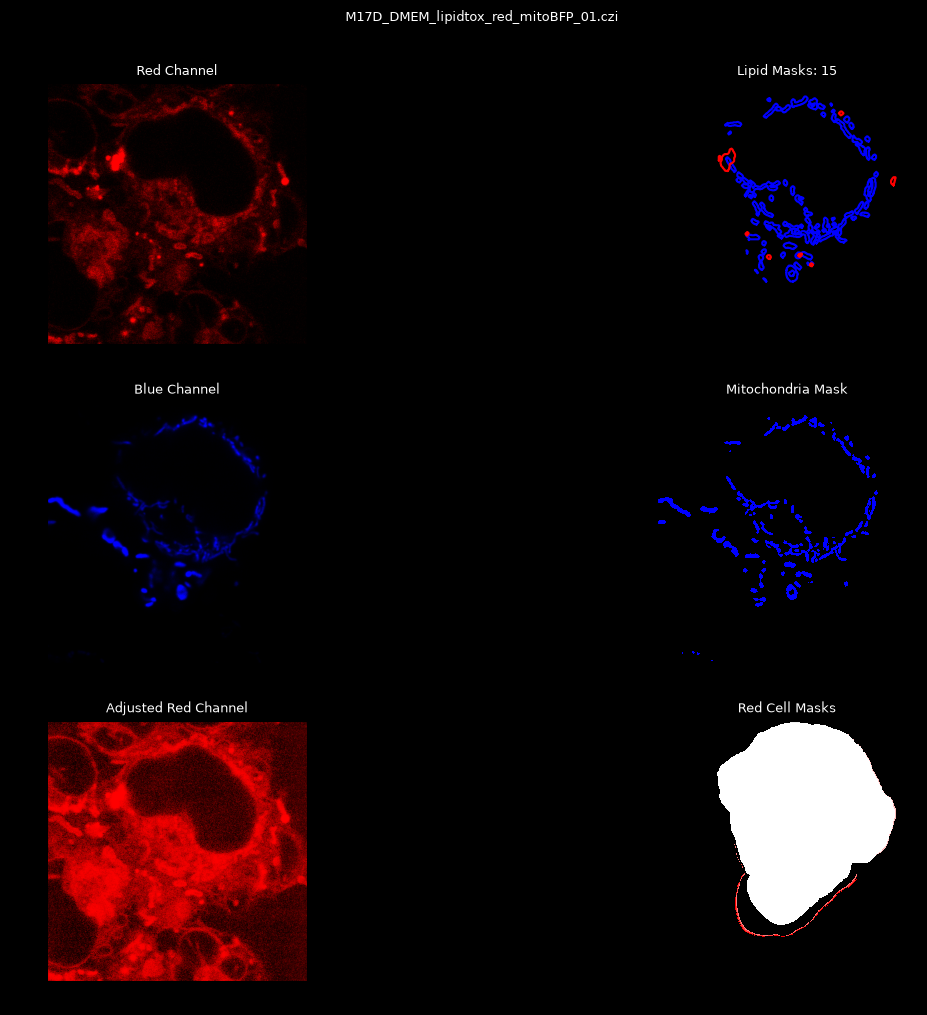

Processing M17D_DMEM_lipidtox_red_mitoBFP_02.czi
    Single pass:     8 masks
    Final cells:     3
Lipid Pixels: 3179
Circularity Index: 1.023576169597728
Perimeter: 35.21320343559643
118.56221995222593
110.30865786510141
84.14570696119915
77.79460135510689
83.43860018001261
115.6027681329474
49.64876634922564
75.59100475585703
75.43208866258443
102.85912696499032
87.72684879784524
115.87061750072795
0.0
87.93179174792243
65.11528238439882
60.0
117.42657280190033
95.00526301210897
0.0
6.082762530298219
48.0
19.79898987322333
40.024992192379
0.0
82.15229759416349
12.649110640673518
102.35721762533407
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_02.czi
Total Cells: 3
Total Lipids: 15


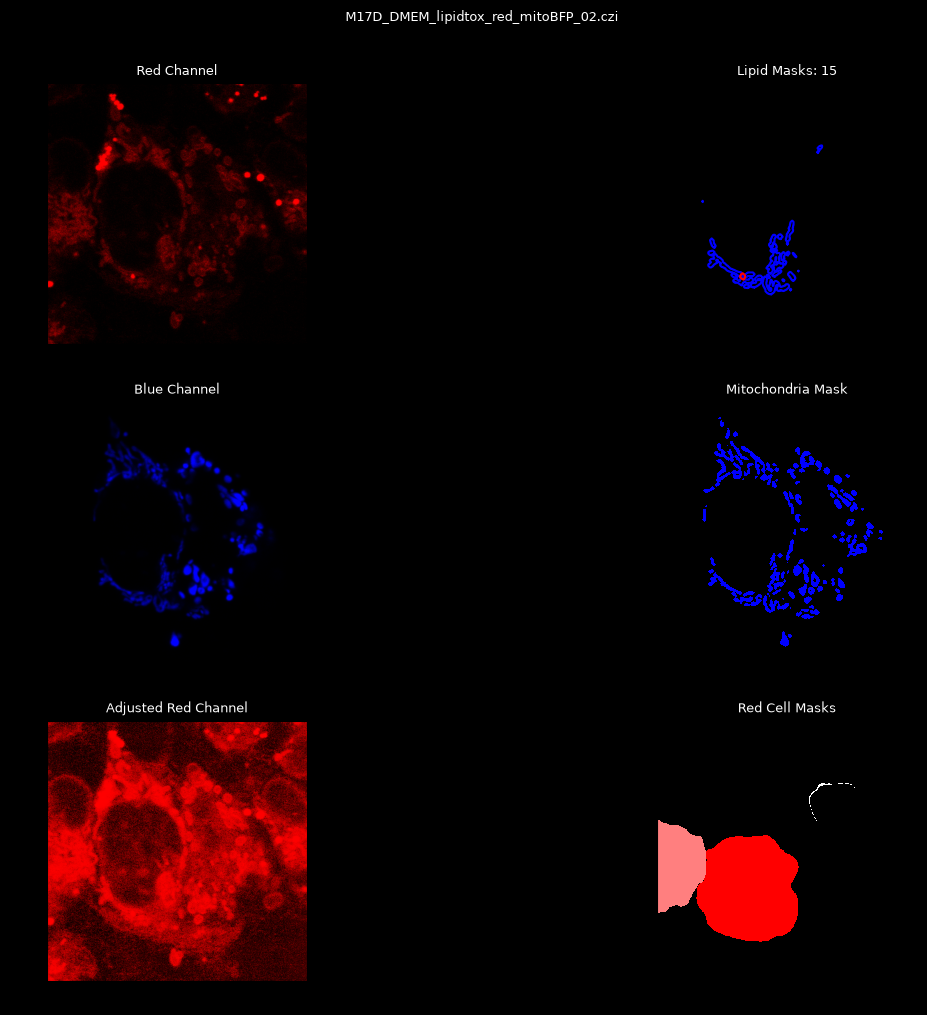

Processing M17D_DMEM_lipidtox_red_mitoBFP_03.czi
    Single pass:     14 masks
    Final cells:     5
Lipid Pixels: 4588
Circularity Index: 0.9691257978623931
Perimeter: 50.2842712474619
55.731499172371095
24.041630560342615
37.0
55.226805085936306
62.93647591023825
61.032778078668514
63.12685640834652
131.8256424221024
86.83317338436964
84.15461959987698
95.2732911156112
92.97311439335567
91.13725912051558
104.34557968596465
108.81176406988355
114.16216536138407
131.59027319676784
170.23806859806652
154.11683879446787
159.81239000778382
174.9771413642365
176.77386684688435
179.7386992275175
Circularity Index: 0.983933545279545
Perimeter: 48.87005768508881
65.5133574166368
28.284271247461902
0.0
7.0710678118654755
16.55294535724685
17.69180601295413
12.36931687685298
108.70602559196064
50.0
42.42640687119285
53.03772242470448
48.41487374764082
40.19950248448356
56.36488268416781
62.76941930590086
67.4166151627327
89.02246907382428
135.47324459095236
103.12128781197411
110.1135777277262

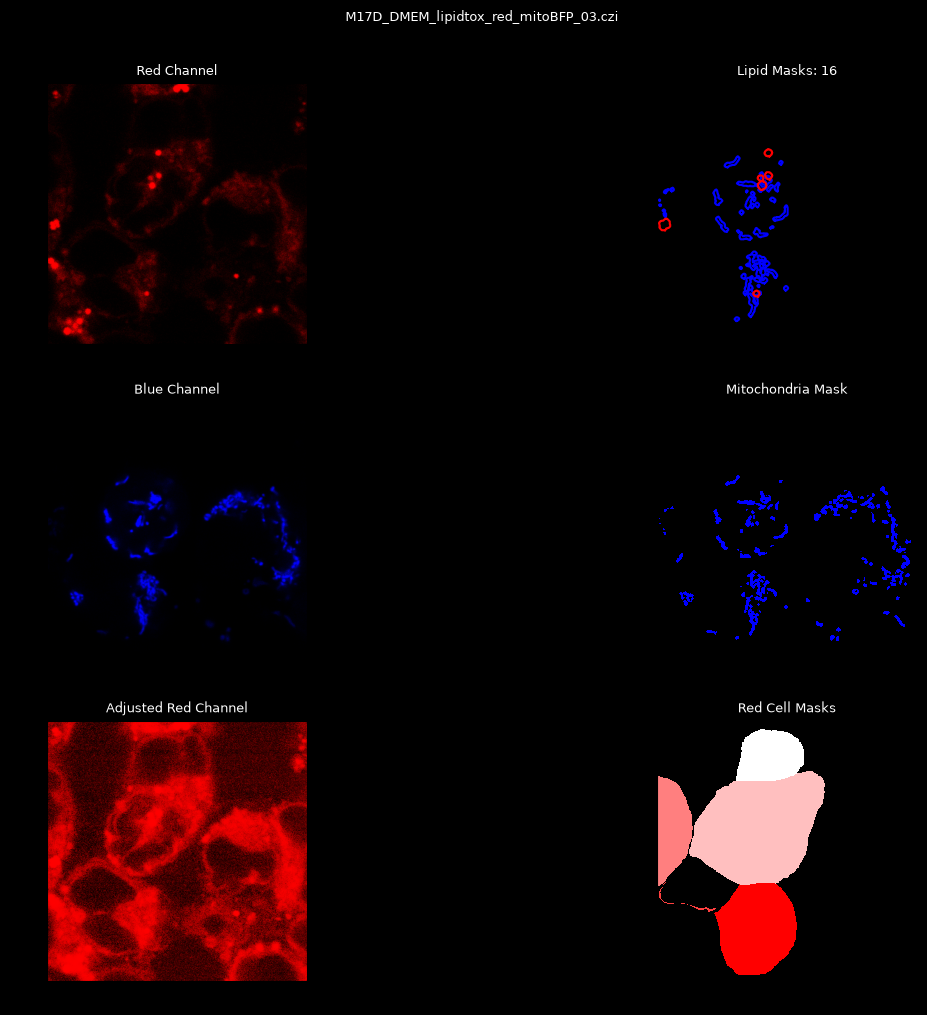

Processing M17D_DMEM_lipidtox_red_mitoBFP_04.czi
    Single pass:     5 masks
    Final cells:     3
Lipid Pixels: 6929
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_04.czi
Total Cells: 3
Total Lipids: 50


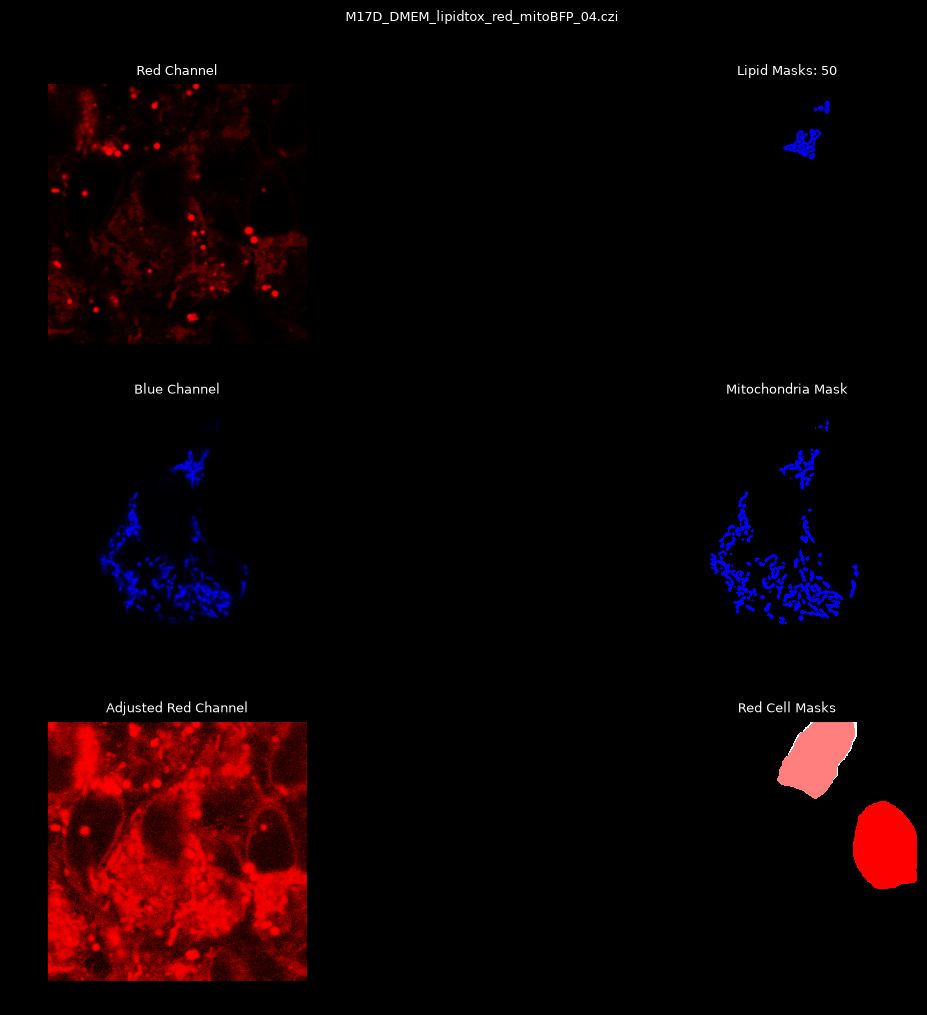

Processing M17D_DMEM_lipidtox_red_mitoBFP_05.czi
    Single pass:     9 masks
    Final cells:     3
Lipid Pixels: 1712
Circularity Index: 0.7332295911161201
Perimeter: 55.07716446627535
0.0
24.839484696748443
Circularity Index: 0.6352048271109019
Perimeter: 37.21320343559643
25.45584412271571
10.198039027185569
1.4142135623730951
0.0
13.416407864998739
Circularity Index: 0.7705040125117667
Perimeter: 22.485281374238568
34.438350715445125
41.72529209005013
58.66856057549052
49.09175083453431
41.97618372363071
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_05.czi
Total Cells: 3
Total Lipids: 11


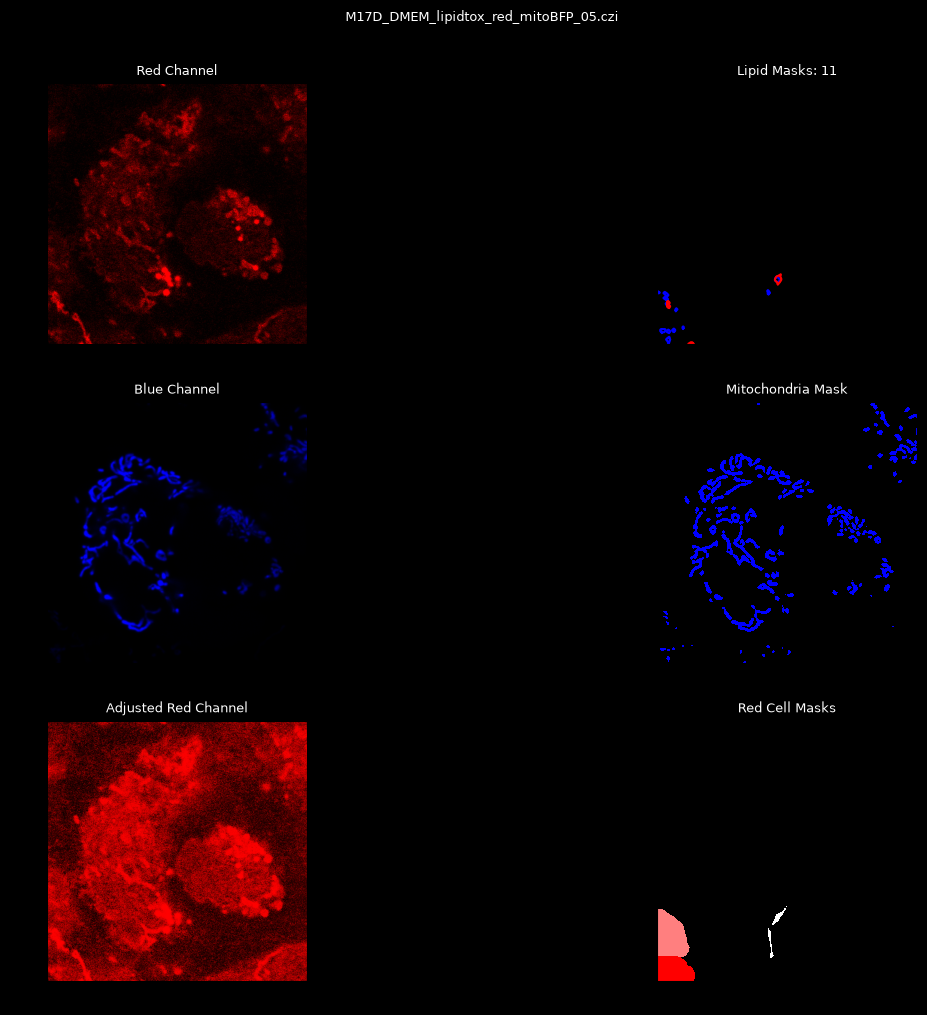

Processing M17D_DMEM_lipidtox_red_mitoBFP_06.czi
    Single pass:     18 masks
    Final cells:     11
Lipid Pixels: 3703
Circularity Index: 0.7691463170874288
Perimeter: 118.8111831820431
38.47076812334269
121.75795661885921
25.0
10.606601717798213
15.652475842498529
0.0
121.1486689980538
0.0
20.396078054371138
1.0
0.0
107.0
99.18165152889924
110.47624178980746
25.0
19.79898987322333
16.278820596099706
9.0
13.601470508735444
55.226805085936306
89.64373932405988
80.61017305526642
64.8459713474939
66.21933252457322
74.16872656315464
91.92388155425118
97.40636529508737
101.11874208078342
Circularity Index: 0.8044823993514747
Perimeter: 63.11269837220809
128.2653499585917
145.3616180427282
126.87395319765204
97.8008179924892
121.93850909372314
81.25269226308751
107.48953437428223
86.55634003352961
120.20815280171308
90.50966799187809
65.55150646628954
93.08598175880189
80.2807573457052
62.96824596572466
94.33981132056604
89.62700485902673
83.40863264674707
58.68986283848344
44.40720662234

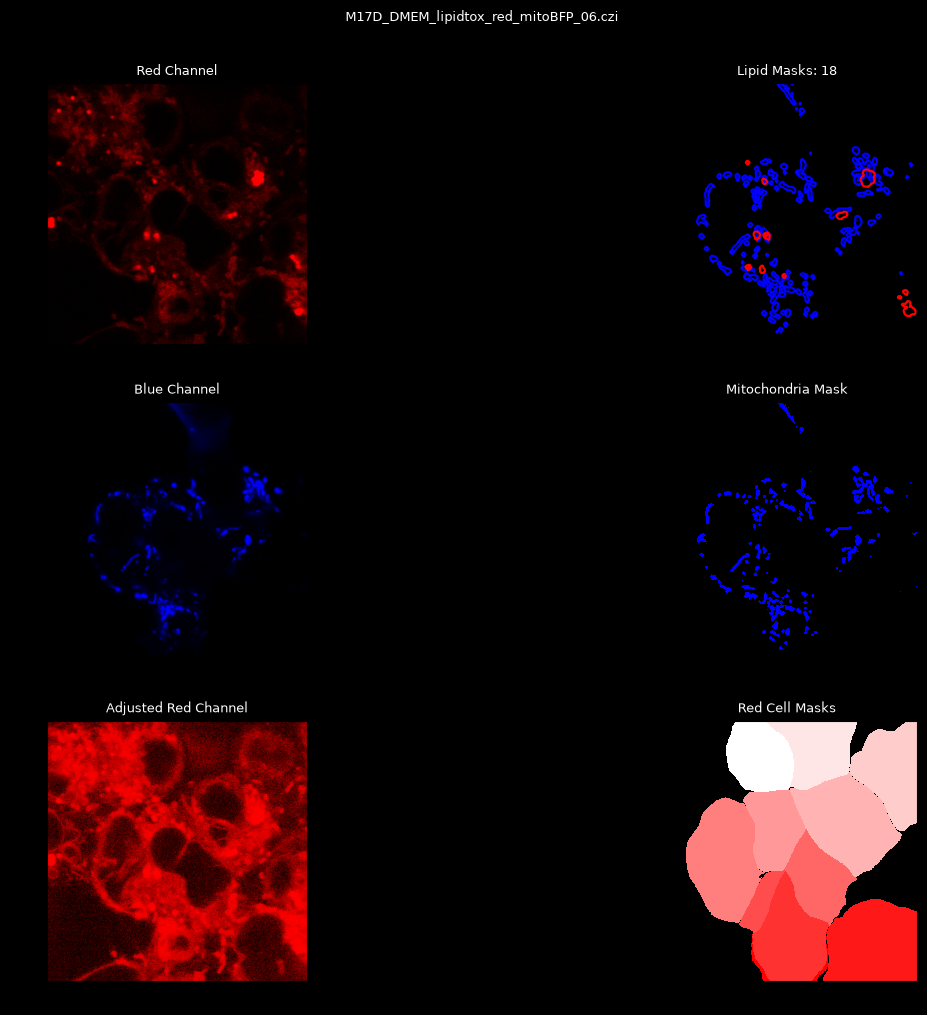

Processing M17D_DMEM_lipidtox_red_mitoBFP_07.czi
    Single pass:     10 masks
    Final cells:     5
Lipid Pixels: 6348
Circularity Index: 0.6295199736980807
Perimeter: 60.76955262170047
25.495097567963924
87.13208364316786
29.410882339705484
102.83968105745953
111.83022847155415
Circularity Index: 0.7418029764711829
Perimeter: 62.2842712474619
104.12012293500234
50.08991914547278
65.92419889539804
14.0
107.0
67.0
92.02173656261873
35.014282800023196
1.0
81.09870529176159
66.61080993352356
0.0
14.142135623730951
25.495097567963924
91.44397191723465
39.66106403010388
13.038404810405298
26.16295090390226
75.61084578286372
14.7648230602334
65.29931086925804
35.35533905932738
20.615528128088304
19.0
60.74537019394976
80.45495634204272
41.012193308819754
67.47592163134935
36.235341863986875
37.20215047547655
43.56604182158393
75.0066663703967
45.17742799230607
41.43669871020132
97.20082304178294
89.09545442950498
89.80256121069154
65.76093065034893
77.78174593052023
57.0350769263968
63.031

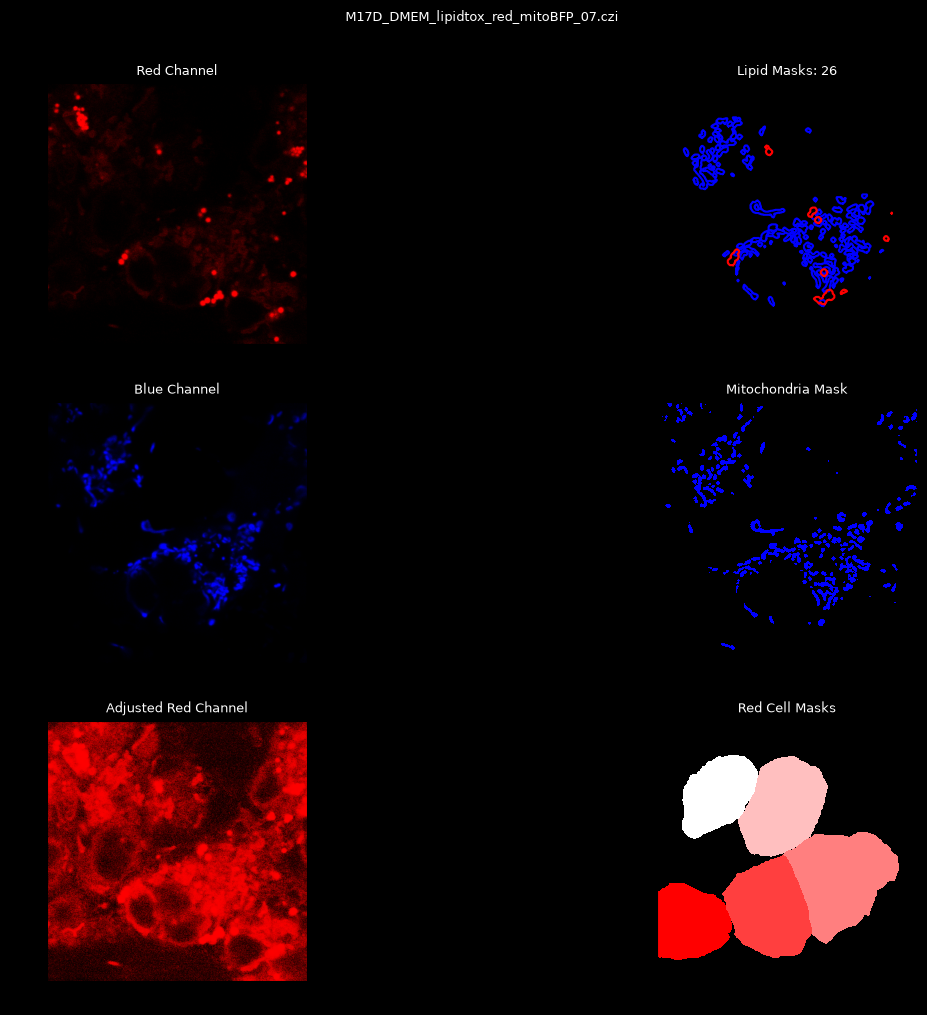

Processing M17D_DMEM_lipidtox_red_mitoBFP_08.czi
    Single pass:     5 masks
    Final cells:     4
Lipid Pixels: 7208
Circularity Index: 1.1065010026804611
Perimeter: 21.31370849898476
57.56735185849702
56.92099788303083
57.0087712549569
9.192388155425117
37.013511046643494
14.142135623730951
0.7071067811865476
39.0
76.10519036176179
57.723478758647246
15.556349186104045
79.42921376924235
42.720018726587654
25.0
126.84636376341263
43.01162633521314
90.4267659490264
49.72926703662542
94.17536832951598
131.7269904006009
96.16652224137046
142.00352108310554
102.44998779892558
114.97825881443848
118.79393923933998
95.38343671728336
113.87712676389407
122.41323457861898
131.88252348207476
145.0551619212498
140.470637501223
158.3729774930054
156.97770542341354
173.92527130926086
169.53170794869024
188.43035848822237
Circularity Index: 0.8982117667033336
Perimeter: 70.87005768508881
74.95331880577403
74.21590126111789
74.04052944165107
3.5355339059327378
50.204581464244875
32.0624390837628


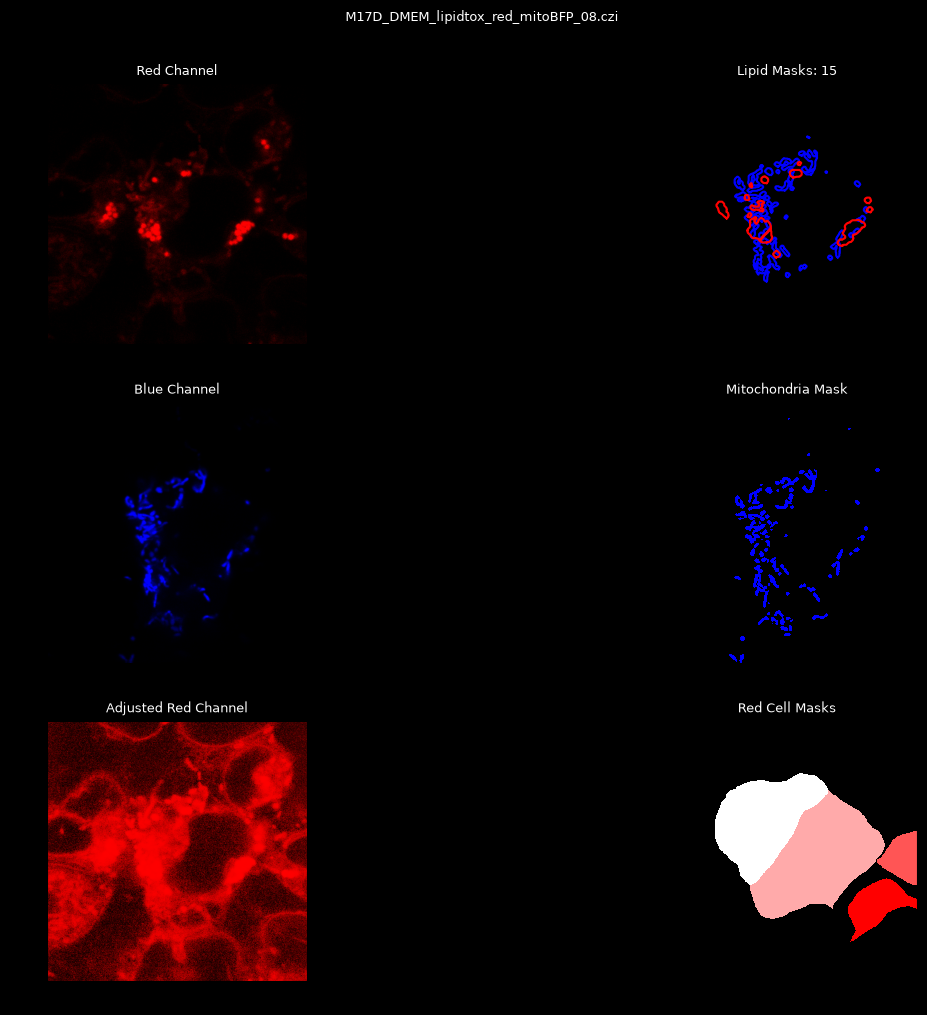

Processing M17D_HBSS_lipidtox_red_mitoBFP_01.czi
    Single pass:     7 masks
    Final cells:     4
Lipid Pixels: 8234
Circularity Index: 0.7998586628791429
Perimeter: 82.66904755831214
72.02777242147643
12.649110640673518
48.373546489791295
32.57299494980466
42.15447781671598
24.041630560342615
52.92447448959697
10.295630140987
21.920310216782973
83.54639429682169
63.60031446463138
75.0
15.524174696260024
51.03920062069938
56.60388679233962
98.76234100101111
37.476659402887016
47.38143096192854
28.0
71.8679344353238
77.93587107359485
87.65842800324451
34.058772731852805
43.01162633521314
104.70912090166739
41.23105625617661
105.6882207249228
101.51354589413178
100.16985574512923
51.86520991955976
48.662100242385755
114.06138698087096
115.00434774390054
117.72000679578642
70.03570517957252
58.309518948453004
94.2019108086455
128.8875478857442
123.0447073221762
147.13938969562162
141.4213562373095
109.48059188732951
61.09828148156051
69.31810730249349
111.12605455067681
70.710678118654

C:\Users\jmp732\AppData\Local\Temp\ipykernel_11336\1875039510.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  circ_index = 4 * np.pi * area / (per ** 2) #Note: account for


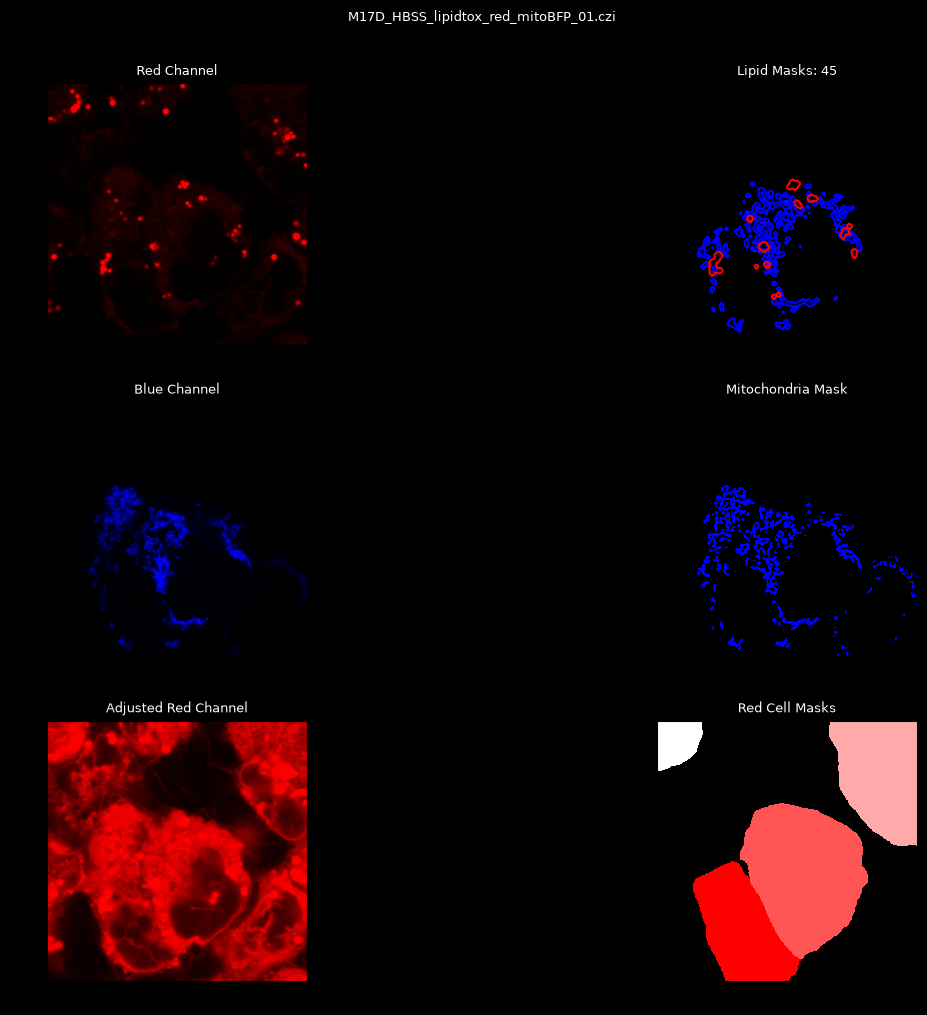

Processing M17D_HBSS_lipidtox_red_mitoBFP_02.czi
    Single pass:     8 masks
    Final cells:     6
Lipid Pixels: 14866
Circularity Index: 0.6259084538292101
Perimeter: 103.1543289325507
33.97057550292606
26.1725046566048
29.546573405388315
51.088159097779204
43.840620433565945
37.8021163428716
59.09314681077663
72.00694410957877
69.02897942168927
82.96987405076617
91.67878707749138
96.60745312862771
88.36288813749809
96.17692030835673
104.92378186092989
110.0
123.68508398347798
131.03434664239754
140.29255147726127
Circularity Index: 0.7006882348599288
Perimeter: 35.17766952966369
50.635955604688654
2.0
33.83784863137726
42.485291572496
55.71355310873648
47.4236228055175
38.0
48.05205510693585
55.65968020030299
78.54934754662193
93.33809511662427
73.00684899377592
79.20227269466452
79.1012010022604
87.0
96.1041102138717
113.54734695271397
118.35962149314267
123.00406497347964
Circularity Index: 1.0789583326647456
Perimeter: 28.14213562373095
19.924858845171276
75.50496672405067
40.71

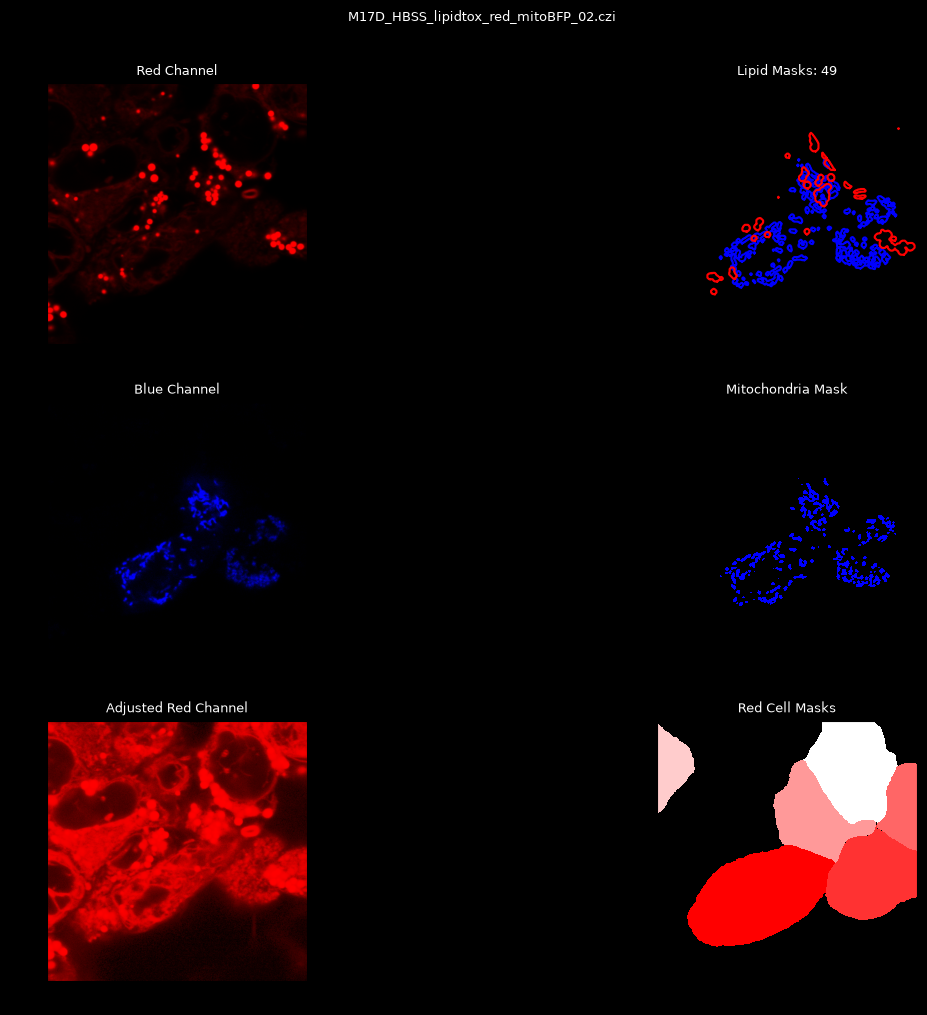

Processing M17D_HBSS_lipidtox_red_mitoBFP_03.czi
    Single pass:     16 masks
    Final cells:     9
Lipid Pixels: 12260
Circularity Index: 1.0006944827171358
Perimeter: 16.621320343559642
126.25371281669304
Circularity Index: 0.8861839530929816
Perimeter: 50.941125496954285
144.9310180741169
Circularity Index: 1.0033752927192359
Perimeter: 32.62741699796952
100.0
Circularity Index: 1.0576623150433915
Perimeter: 31.213203435596427
99.72462083156798
Circularity Index: 0.8125715142026816
Perimeter: 105.1543289325507
37.12142238654117
Circularity Index: 0.7537528560791962
Perimeter: 84.66904755831214
147.82760229402356
Circularity Index: 1.612290114395414
Perimeter: 8.82842712474619
86.53323061113575
54.378304497290095
101.17806086301516
129.24782396620841
112.69871339105873
134.16407864998737
127.56566936288148
143.37712509323097
144.68241081762497
166.97305171793442
167.45148551147582
Circularity Index: 0.9366215257313841
Perimeter: 77.35533905932738
22.627416997969522
123.0
4.0
31.819

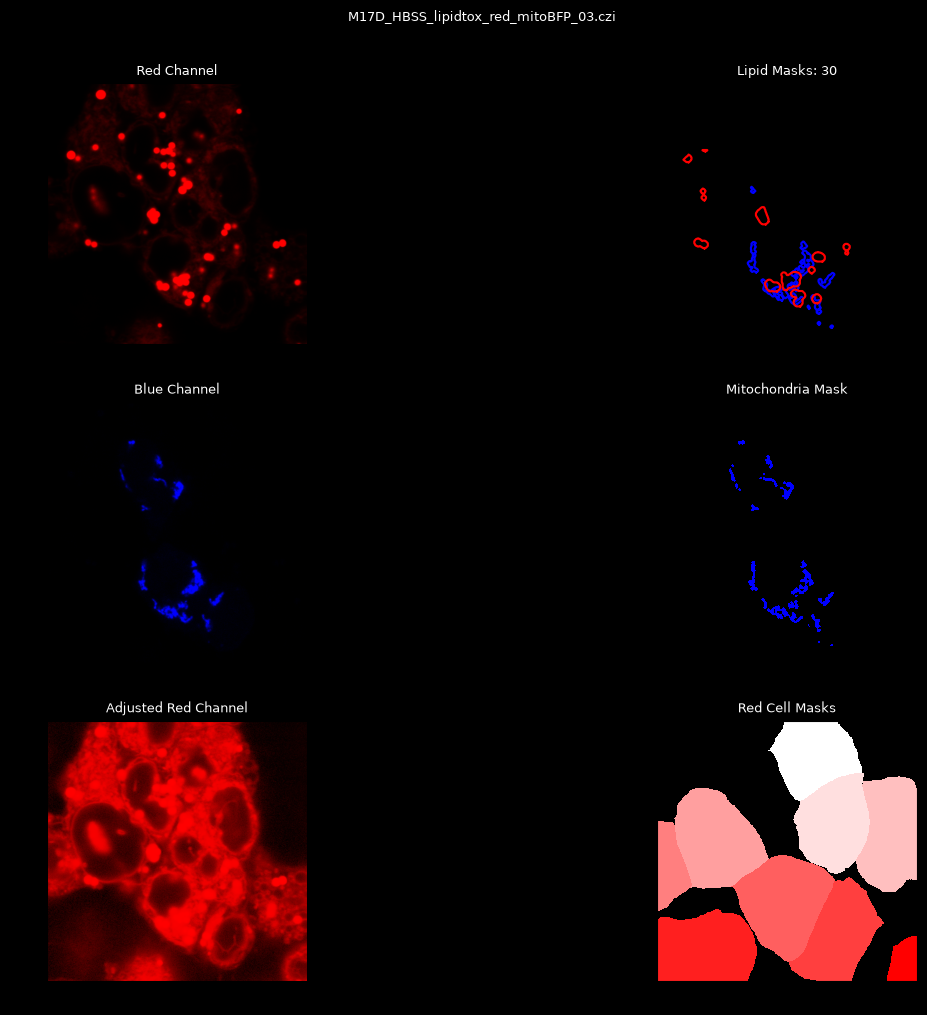

Processing M17D_HBSS_lipidtox_red_mitoBFP_04.czi
    Single pass:     17 masks
    Final cells:     16
Lipid Pixels: 9562
Circularity Index: 1.110364893972453
Perimeter: 34.14213562373095
2.0
0.0
14.317821063276353
11.180339887498949
53.33854141237835
44.40720662234904
2.8284271247461903
60.876925020897694
60.440052945046304
59.77457653551382
Circularity Index: 0.8647647129933892
Perimeter: 49.55634918610404
45.17742799230607
67.47592163134935
74.81310045707235
78.29431652425353
78.0
91.7877987534291
96.33794683301072
92.72000862812729
110.46266337545913
150.8011936292283
130.86252328302402
161.19863522995473
168.77203559831824
215.8077848456816
204.35385976291224
210.71782079359116
225.56706319850866
Circularity Index: 0.9286791058917584
Perimeter: 44.14213562373095
5.385164807134504
71.8679344353238
77.79460135510689
68.46897107449476
86.76404785393545
106.17438485811914
111.64676439557037
111.50336317797773
133.9589489358587
178.89941307897016
156.348968656656
190.31815467789718
198

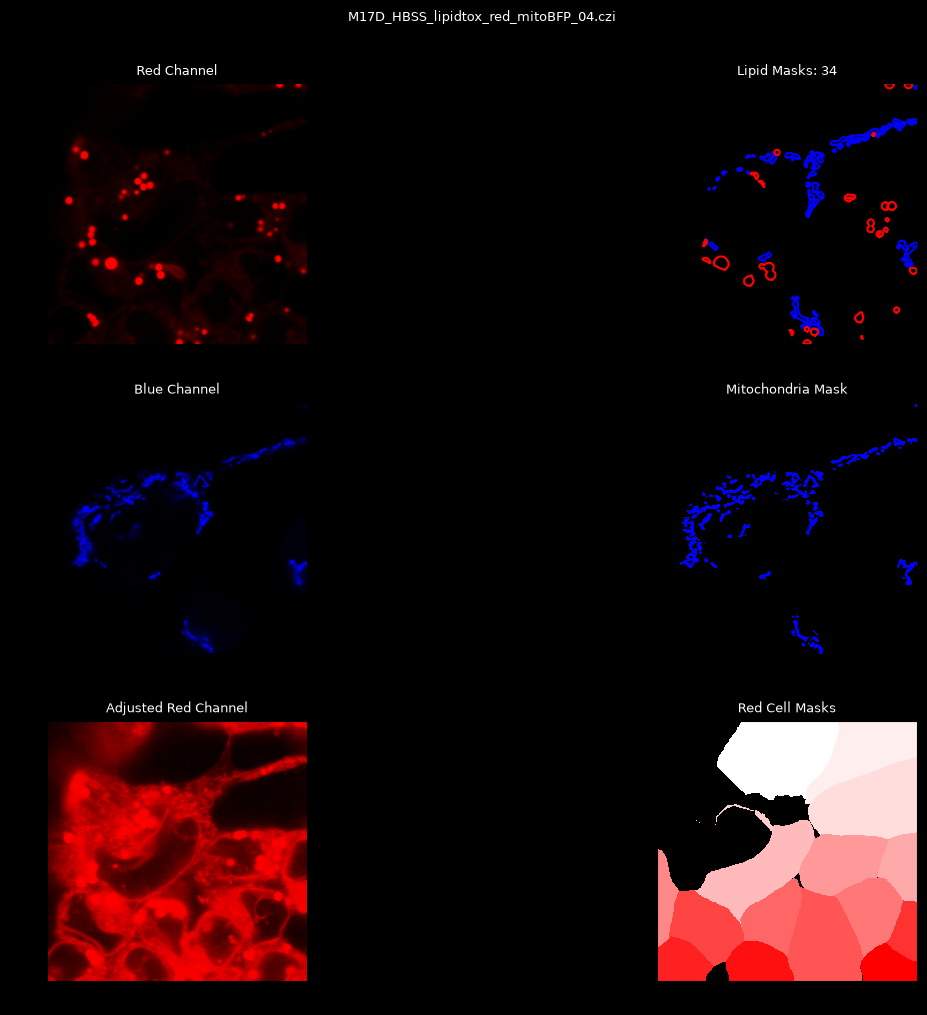

Processing M17D_HBSS_lipidtox_red_mitoBFP_05.czi
    Single pass:     16 masks
    Final cells:     13
Lipid Pixels: 1751
Circularity Index: 0.8726868867141326
Perimeter: 28.142135623730947
137.2443077143821
111.40017953306898
94.92101980067429
133.75350462698165
108.66922287382016
101.20276676059801
100.60318086422517
91.6624241442479
149.27156460625713
140.12851244482687
159.0
149.00335566691106
133.37541002748594
165.00303027520434
136.49908424601244
164.10362579784763
97.98469268207153
113.03096920755833
39.05124837953327
128.09761902549164
86.4060183089118
36.062445840513924
59.90826320300064
52.20153254455275
121.16517651536682
135.1628647225265
44.204072210600685
81.41252974819048
84.21995013059554
87.13208364316786
115.15641536623133
134.33167906342868
169.29264603047588
70.03570517957252
117.33712115098103
71.50524456289902
107.91200118615167
120.2538980657176
Circularity Index: 0.8000531832338149
Perimeter: 91.49747468305833
65.19202405202648
47.29693436154187
41.0
48.0208288

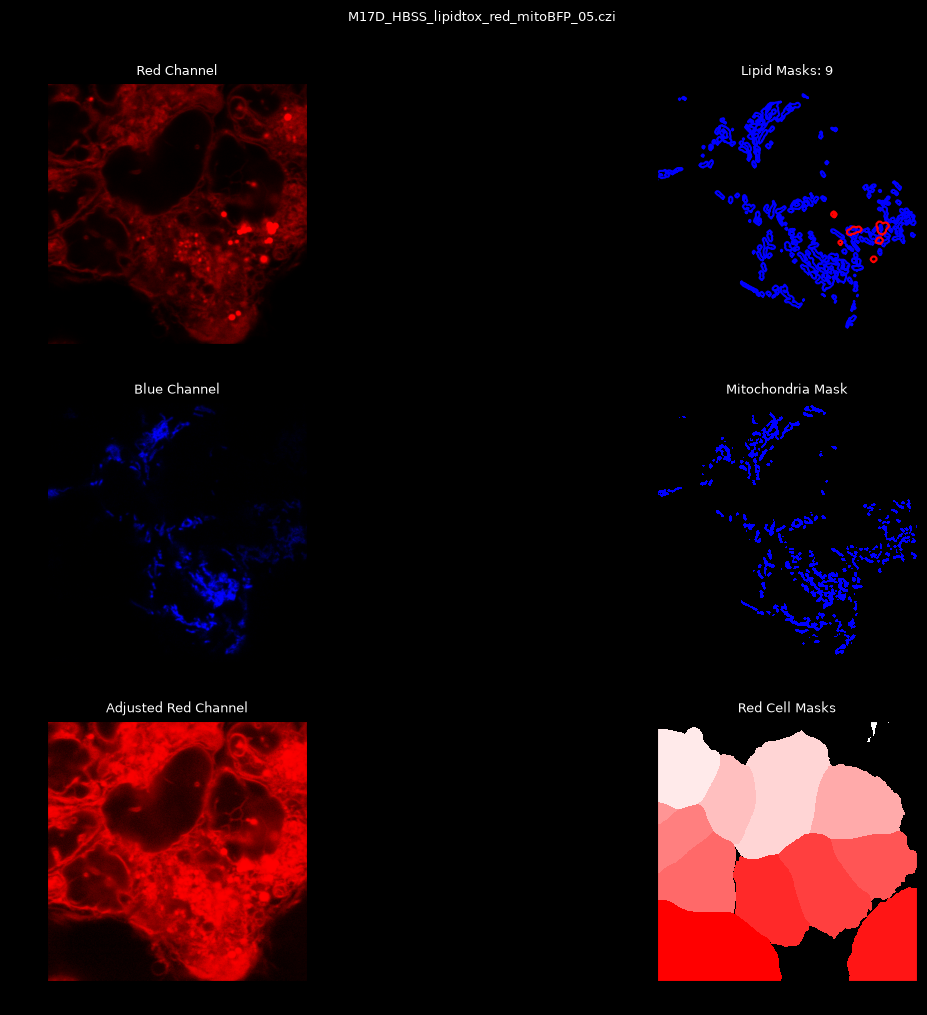

Processing M17D_HBSS_lipidtox_red_mitoBFP_06.czi
    Single pass:     8 masks
    Final cells:     5
Lipid Pixels: 8904
Circularity Index: 0.8196957955564398
Perimeter: 52.384776310850235
126.763559432512
127.1416532848303
131.18307817702708
Circularity Index: 0.9734101918540952
Perimeter: 48.87005768508881
70.83784299369935
71.47027354082255
78.77182237323191
Circularity Index: 0.9820715413787474
Perimeter: 47.45584412271571
164.59647626847908
163.68872899500442
154.042202009709
Circularity Index: 0.9978017678433251
Perimeter: 57.11269837220809
113.21660655575224
112.28535078094559
102.59142264341595
Circularity Index: 0.8440788568196304
Perimeter: 50.45584412271571
126.58988901172162
125.23977004130916
110.90987332063814
Circularity Index: 0.9753287442579102
Perimeter: 56.526911934581186
25.495097567963924
36.49657518178932
0.0
43.41658669218482
12.36931687685298
23.345235059857504
0.7071067811865476
7.7781745930520225
9.0
105.90561835898981
53.33854141237835
33.421549934136806
32.52

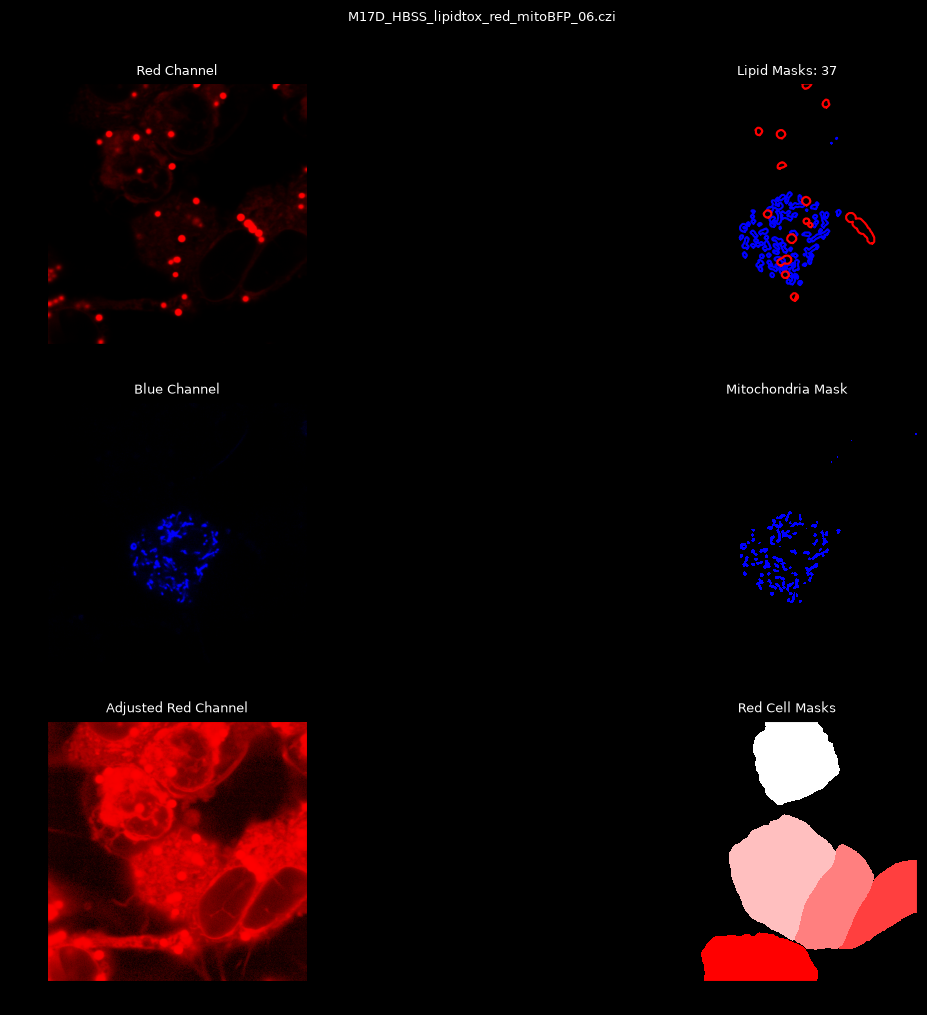

Processing M17D_HBSS_lipidtox_red_mitoBFP_07.czi
    Single pass:     9 masks
    Final cells:     7
Lipid Pixels: 4237
Circularity Index: 0.6981151621255222
Perimeter: 34.72792206135785
0.0
86.16263691415206
45.254833995939045
72.42237223399962
60.10407640085654
110.98198051936178
52.92447448959697
72.8319984622144
99.82484660644363
89.80256121069154
135.36986370680884
112.69871339105873
102.59142264341595
94.51454914456292
102.7277956543408
113.13708498984761
120.88010589009261
126.572113832392
91.0823802938856
107.78218776773832
119.54078801814885
130.66751700403586
132.4009063413087
121.07848694132248
117.17508267545622
192.04166214652486
167.35590817177624
Circularity Index: 0.9805467826824814
Perimeter: 53.698484809834994
93.38094023943002
0.0
59.20304046246274
33.015148038438355
38.27531841800928
16.278820596099706
66.06814663663572
46.75467891024384
29.068883707497267
47.80167361086848
45.31004303683677
45.5411901469428
58.137767414994535
66.18912297349165
79.05694150420949
57.

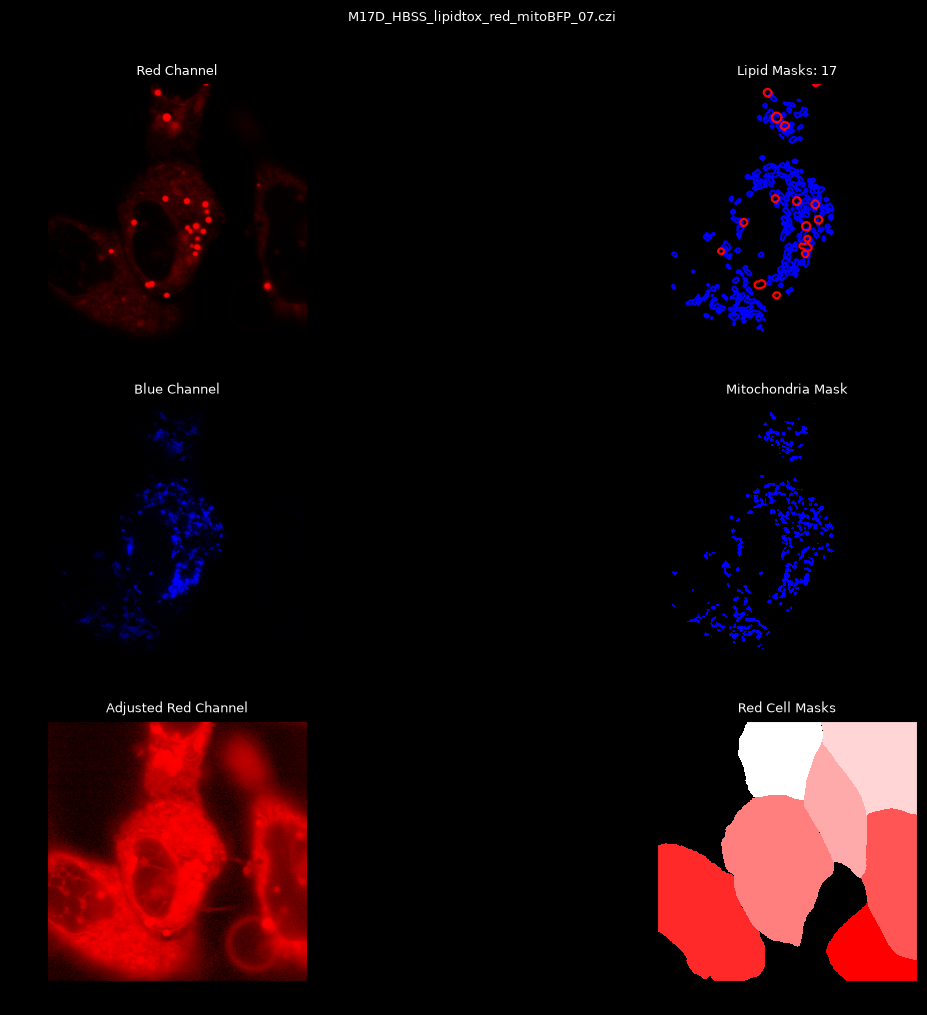

Processing M17D_HBSS_lipidtox_red_mitoBFP_08.czi
    Single pass:     11 masks
    Final cells:     11
Lipid Pixels: 6617
Circularity Index: 0.9594784761831847
Perimeter: 65.94112549695429
83.48652585896721
92.69843580125827
96.04686356149273
96.5090669315583
107.20541031123382
105.38500842150178
159.11316727411344
117.44360348695028
123.8587905640936
147.85127662620977
117.09824934643558
127.12198865656563
163.783393541592
158.8238017426859
Circularity Index: 0.9062451540853318
Perimeter: 18.242640687119284
76.55063683601855
67.4166151627327
105.11898020814318
110.16805344563369
90.27181176868004
119.97082978791136
196.2090721653818
124.85191228010886
200.4195599236761
140.54536634126364
220.41778512633684
215.67800073257357
201.80436070610565
209.30360723121808
231.22499864850255
135.9154148726332
141.9929575718458
239.7269279826528
160.822883943797
239.70815588961506
251.09759058979438
220.83930809527547
231.89868477419185
214.80456233516085
245.36605307173198
242.5376259469858
246.

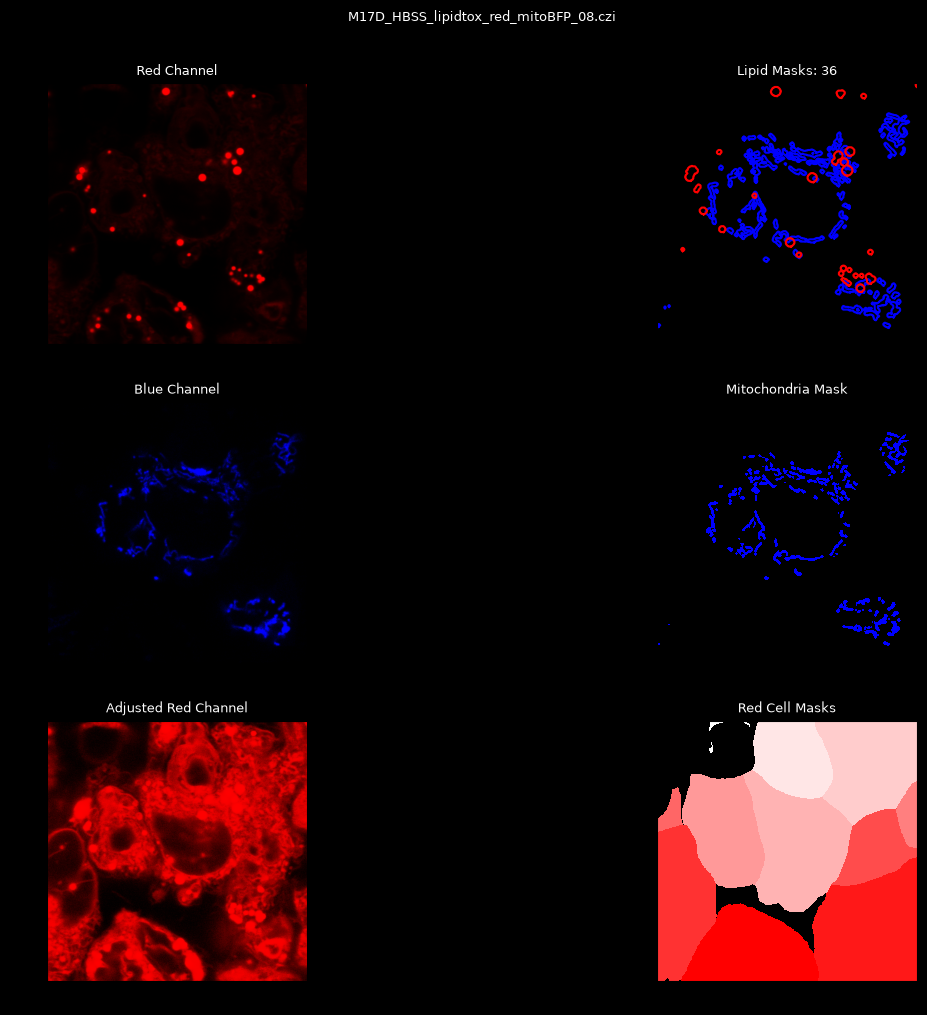

All files processed


In [4]:
# color maps
cmap_green = LinearSegmentedColormap.from_list("G", [(0,0,0),(0,1,0)])
cmap_red   = LinearSegmentedColormap.from_list("R", [(0,0,0),(1,0,0)])
cmap_red_inv = LinearSegmentedColormap.from_list("RI", [(1, 1, 1),(1,0,0)])
cmap_blue = LinearSegmentedColormap.from_list("B", [(0, 0, 0), (0, 0, 1)])

all_results = []

image_files = sorted(glob.glob(os.path.join(IMAGE_FOLDER, FILE_EXTENSION)))
print(f"Found {len(image_files)} file(s) in {IMAGE_FOLDER}")

for filepath in image_files:
    filename = os.path.basename(filepath)
    print(f"Processing {filename}")

    """
    Load Channels:
    1. Red: Lipid Droplets
    2. Blue: Mitochondria
    """
    red_raw, blue_raw = load_channels(filepath)
    if red_raw is None or blue_raw is None:
        print("Load Error: skipping file")
        continue
    blue_adjusted = exposure.equalize_hist(blue_raw)
    red_adjusted = exposure.equalize_hist(red_raw)

    red_norm = normalize_image(red_raw)
    red_uint8 = (red_norm * 255).astype(np.uint8)

    #segment cells
    labeled_cells = segment_cells_single_pass(blue_adjusted, red_adjusted)
    if labeled_cells is None:
        print("  Unable to segment red cells")

    #retrieve mitochondria mask
    mito_mask = segment_mito_adaptive(blue_raw)

    #retrieve lipid mask
    lipid_mask = segment_lipids_otsu(red_raw)
    labeled_lipids = label(lipid_mask)
    print(f"Lipid Pixels: {lipid_mask.sum()}")

    #calculate lipid mfi for every cell
    mfi_data, mito_shapes, lipid_shapes = analyze_MFI(red_raw, lipid_mask, labeled_cells, mito_mask)

    #summary
    n_cells = np.max(labeled_cells)
    n_lipids = np.max(labeled_lipids)
    print(f"SUMMARY {filename}")
    print(f"Total Cells: {n_cells}")
    print(f"Total Lipids: {n_lipids}")

    #visualization
    H, W = lipid_mask.shape
    cell_display = np.where(labeled_cells > 0, labeled_cells, np.nan)
    cellmito_display = np.where(mito_mask, 100, cell_display)
    lipid_display = np.where(labeled_lipids > 0, labeled_lipids, np.nan)
    blank_display = np.where(lipid_mask, np.nan, np.nan)

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
    fig.patch.set_facecolor("black")
    fig.suptitle(filename, color="white", fontsize=9, y=1.01)

    axes[0][0].imshow(boost_contrast_visual(red_raw), cmap=cmap_red)
    axes[0][0].set_title("Red Channel", color="white", fontsize=9)

    axes[0][1].set_facecolor("black")
    axes[0][1].imshow(blank_display)
    for shape in mito_shapes:
        x, y = shape.exterior.xy
        axes[0][1].plot(y, x, color="b")

    for shape in lipid_shapes:
        x, y = shape.exterior.xy
        axes[0][1].plot(y, x, color="r")
    axes[0][1].set_title(f"Lipid Masks: {n_lipids}", color="white", fontsize=9)

    axes[1][0].imshow(boost_contrast_visual(blue_raw), cmap=cmap_blue)
    axes[1][0].set_title("Blue Channel", color="white", fontsize=9)

    axes[1][1].set_facecolor("black")
    axes[1][1].imshow(mito_mask, cmap=cmap_blue, interpolation="none")
    axes[1][1].set_title(f"Mitochondria Mask", color="white", fontsize=9)

    axes[2][0].set_facecolor("white")
    axes[2][0].imshow(red_adjusted, cmap=cmap_red)
    axes[2][0].set_title("Adjusted Red Channel", color="white", fontsize=9)

    axes[2][1].set_facecolor("black")
    axes[2][1].imshow(cell_display, cmap=cmap_red_inv, interpolation="none")
    axes[2][1].set_title(f"Red Cell Masks", color="white", fontsize=9)

    plt.tight_layout()
    plt.show()

    #collect data row per-lipid
    for cell_id, info in mfi_data.items(): #returns (key, value) pairs
        all_results.append({
            "Filename" : filename,
            "Cell ID" : info["cell_id"],
            "Cell Area (px)" : info["cell_area"],
            "Mitochondria SA (px)" : info["mito_area"],
            "Lipid MFI" : round(info["lipid_mfi"], 5),
            "# of Lipids" : info["#lipids"],
            "Lipid Area (px)" : info["lipid_area"],
            "Single Lipids" : info["n_single"],
            "Single Lipids Area" : info["single_area"],
            "Clustered Lipids" : info["n_clustered"],
            "Clustered Lipid Area" : info["clustered_area"], 
        })


print("All files processed")


Save Results to CSV

In [27]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

if not all_results:
    print("No results to save")
else:
    df = pd.DataFrame(all_results)

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Lipid MFI Per Cell"

    headers = list(df.columns)

    header_fill = PatternFill("solid", start_color="C20000")
    header_font = Font(bold=True, color="FFFFFF", name="Arial", size=11)
    center_align = Alignment(horizontal="center", vertical="center")
    left_align = Alignment(horizontal="left", vertical="center")

    thin_border = Border(
        bottom=Side(style="thin", color="AAAAAA"),
        right=Side(style="thin", color="AAAAAA")
    )

    #Header Row
    for col_index, header in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col_index, value=header)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align
        cell.border = thin_border

    ws.row_dimensions[1].height = 34

    alt_fill = PatternFill("solid", start_color="F0D9D6")

    #Data Rows
    for r_idx, row in enumerate(df.itertuples(index=False), start=2):
        fill = alt_fill if r_idx % 2 == 0 else None

        for c_idx, val in enumerate(row, start=1):
            try:
                cell = ws.cell(row=r_idx, column=c_idx, value=val)
            except:
                cellVal = ','.join(str(item) for item in val)
                cell = ws.cell(row=r_idx, column=c_idx, value=cellVal)
            if fill:
                cell.fill = fill
            cell.border = thin_border
            cell.font = Font(name="Arial", size=10)
            cell.alignment = left_align if c_idx == 1 else center_align

    widths = [50, 10, 25, 15, 25, 30]
    for i, w in enumerate(widths, 1):
            ws.column_dimensions[get_column_letter(i)].width = w

    ws.freeze_panes = "A2"

    # Save directly as XLSX
    xlsx_path = os.path.join(RESULTS_FOLDER, OUTPUT_FILENAME.replace(".csv", ".xlsx"))
    wb.save(xlsx_path)

    print(f"Output Saved {xlsx_path}")

Output Saved Results\102225_lipid_mfi_per_cell.xlsx
